# **Project Data Analytics**

---



*Oleh Kelompok 3*



*   Christian Bellamy Ahza Kusumadjaja / 2802461246
*   Fausta Bagas Raditya / 2802428734
*   Louis Gerrard Pangestu / 2802391826

## **Set Up & Configuration**

---



### **Import Library**



In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import pearsonr, f_oneway

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Tambahan supaya lebih rapih
import warnings
warnings.filterwarnings('ignore')

## **Data Understanding & Quality Assesment**

---



### **Google Drive Mount**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Load Dataset**

In [ ]:
dir_train = '/content/drive/MyDrive/Pengerjaan Data Analytics/dataset/rossman_store_sales/rossmann-store-sales/train.csv'
train = pd.read_csv(dir_train)
dir_store = '/content/drive/MyDrive/Pengerjaan Data Analytics/dataset/rossman_store_sales/rossmann-store-sales/store.csv'
store = pd.read_csv(dir_store)

### **Merge Dataset**

In [ ]:
df = pd.merge(train, store, on='Store', how='left')

### **Describe the Dataset**

#### *Dataset Preview*

In [ ]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


#### *Dataset Structure*

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

#### *Early Describtive Statistic*

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,1017209.0,558.429727,321.908651,1.0,280.0,558.0,838.0,1115.0
DayOfWeek,1017209.0,3.998341,1.997391,1.0,2.0,4.0,6.0,7.0
Sales,1017209.0,5773.818972,3849.926175,0.0,3727.0,5744.0,7856.0,41551.0
Customers,1017209.0,633.145946,464.411734,0.0,405.0,609.0,837.0,7388.0
Open,1017209.0,0.830107,0.375539,0.0,1.0,1.0,1.0,1.0
Promo,1017209.0,0.381515,0.485759,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,1017209.0,0.178647,0.383056,0.0,0.0,0.0,0.0,1.0
CompetitionDistance,1014567.0,5430.085652,7715.323700,20.0,710.0,2330.0,6890.0,75860.0
CompetitionOpenSinceMonth,693861.0,7.222866,3.211832,1.0,4.0,8.0,10.0,12.0
CompetitionOpenSinceYear,693861.0,2008.690228,5.992644,1900.0,2006.0,2010.0,2013.0,2015.0


### I**dentifying Data Quality Issues**

#### *Missing Value*

In [ ]:
pd.DataFrame({
    "Missing Values" : df.isnull().sum(),
    "Missing Values Percentage" : df.isnull().sum() / len(df) * 100
})

,Missing Values,Missing Values Percentage
Store,0,0.000000
DayOfWeek,0,0.000000
Date,0,0.000000
Sales,0,0.000000
Customers,0,0.000000
Open,0,0.000000
Promo,0,0.000000
StateHoliday,0,0.000000
SchoolHoliday,0,0.000000
StoreType,0,0.000000


#### *Wrong Datatypes and Inconsistencies*

In [ ]:
print(df.dtypes)

Store                          int64
DayOfWeek                      int64
Date                          object
Sales                          int64
Customers                      int64
Open                           int64
Promo                          int64
StateHoliday                  object
SchoolHoliday                  int64
StoreType                     object
Assortment                    object
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                 object
dtype: object


In [ ]:
print(df['StateHoliday'].value_counts())
print(df['StoreType'].value_counts())
print(df['Assortment'].value_counts())
print(df['PromoInterval'].value_counts())

StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64
StoreType
a    551627
d    312912
c    136840
b     15830
Name: count, dtype: int64
Assortment
a    537445
c    471470
b      8294
Name: count, dtype: int64
PromoInterval
Jan,Apr,Jul,Oct     293122
Feb,May,Aug,Nov     118596
Mar,Jun,Sept,Dec     97460
Name: count, dtype: int64


#### *Outliers Found*

In [ ]:
check_cols = ['Sales', 'Customers', 'CompetitionDistance']

for col in check_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  n_out = ((df[col] < lower) | (df[col] > upper)).sum()
  print(f"{col}: {n_out:,} outliers ({n_out/len(df)*100:.1f}%)")

Sales: 26,694 outliers (2.6%)
Customers: 38,095 outliers (3.7%)
CompetitionDistance: 99,160 outliers (9.7%)


#### *Duplicates*

In [ ]:
df.duplicated().sum()

np.int64(0)

## **Data Wrangling & Preprocessing**

---



### **Preparing Dataset for EDA**

In [ ]:
df_eda = df.copy()

### **Cleaning the Dataset**

#### *Fixing Datatypes & Standarization*

In [ ]:
df_eda['Date'] = pd.to_datetime(df_eda['Date'])

In [ ]:
df_eda['StateHoliday'] = df_eda['StateHoliday'].replace({
    '0': 'no_holiday',
    0: 'no_holiday',
    'a': 'public_holiday',
    'b': 'easter_holiday',
    'c': 'christmas'
})

#### *Handling Missing Values*

In [ ]:
df_eda['CompetitionDistance'] = df_eda['CompetitionDistance'].fillna(df_eda['CompetitionDistance'].median())

In [ ]:
df_eda['CompetitionOpenSinceMonth'] = df_eda['CompetitionOpenSinceMonth'].fillna(0)
df_eda['CompetitionOpenSinceYear'] = df_eda['CompetitionOpenSinceYear'].fillna(0)

In [ ]:
df_eda['Promo2SinceWeek'] = df_eda['Promo2SinceWeek'].fillna(0)
df_eda['Promo2SinceYear'] = df_eda['Promo2SinceYear'].fillna(0)
df_eda['PromoInterval'] = df_eda['PromoInterval'].fillna('none')

#### *Drop rows*

In [ ]:
df_eda = df_eda[df_eda['Open'] == 1]

In [ ]:
df_eda = df_eda[~((df_eda['Open'] == 1) & (df_eda['Sales'] == 0))]

#### *Feature Engineering*

In [ ]:
df_eda['Year'] = df_eda['Date'].dt.year
df_eda['Month'] = df_eda['Date'].dt.month
df_eda['WeekOfYear'] = df_eda['Date'].dt.isocalendar().week.astype(int)
df_eda['Quarter'] = df_eda['Date'].dt.quarter

#### *Drop Column*

In [ ]:
df_eda = df_eda.drop(columns=['Open']) # NOTES: Semua kolom Open valuenya '1', artinya redundant jika di keep.

## **Exploratory Data Analysis**

---



### **Column Definition**

In [ ]:
df_eda.info() # NOTES: Cek Dtypes sebelum lanjut.

<class 'pandas.core.frame.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844338 non-null  int64         
 1   DayOfWeek                  844338 non-null  int64         
 2   Date                       844338 non-null  datetime64[ns]
 3   Sales                      844338 non-null  int64         
 4   Customers                  844338 non-null  int64         
 5   Promo                      844338 non-null  int64         
 6   StateHoliday               844338 non-null  object        
 7   SchoolHoliday              844338 non-null  int64         
 8   StoreType                  844338 non-null  object        
 9   Assortment                 844338 non-null  object        
 10  CompetitionDistance        844338 non-null  float64       
 11  CompetitionOpenSinceMonth  844338 non-null  float64     

In [ ]:
numerical_col = df_eda.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_col = df_eda.select_dtypes(include='object').columns.tolist()

exception_col = ['Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'Promo2', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear', 'Day']

"""
Untuk bagian exception_cols, kolom-kolom tersebut tidak dimasukkan ke dalam analisis EDA karena:
- Store -> Bersifat ID/label, tidak memberikan nilai numerik.
- DayOfWeek, Promo, SchoolHoliday, Promo2 -> Bersifat kategorial, sudah dibahas di bawah (Di bagian Modeling).
- CompetitionOpenSinceMonth, CompetitionOpenSinceYear, Promo2SinceWeek, Promo2SinceYear -> Karena dilakukan input, distribusinya terdistorsi.
- Day -> Granularitas terlalu kecil.
"""

numerical_col = [col for col in numerical_col if col not in exception_col]
categorical_col = [col for col in categorical_col if col not in ['PromoInterval']] # Diinput none, distribusi terdistorsi.

print(numerical_col)
print(categorical_col)

['Sales', 'Customers', 'CompetitionDistance', 'WeekOfYear']
['StateHoliday', 'StoreType', 'Assortment']


### **Univariate**

#### *Categorical*

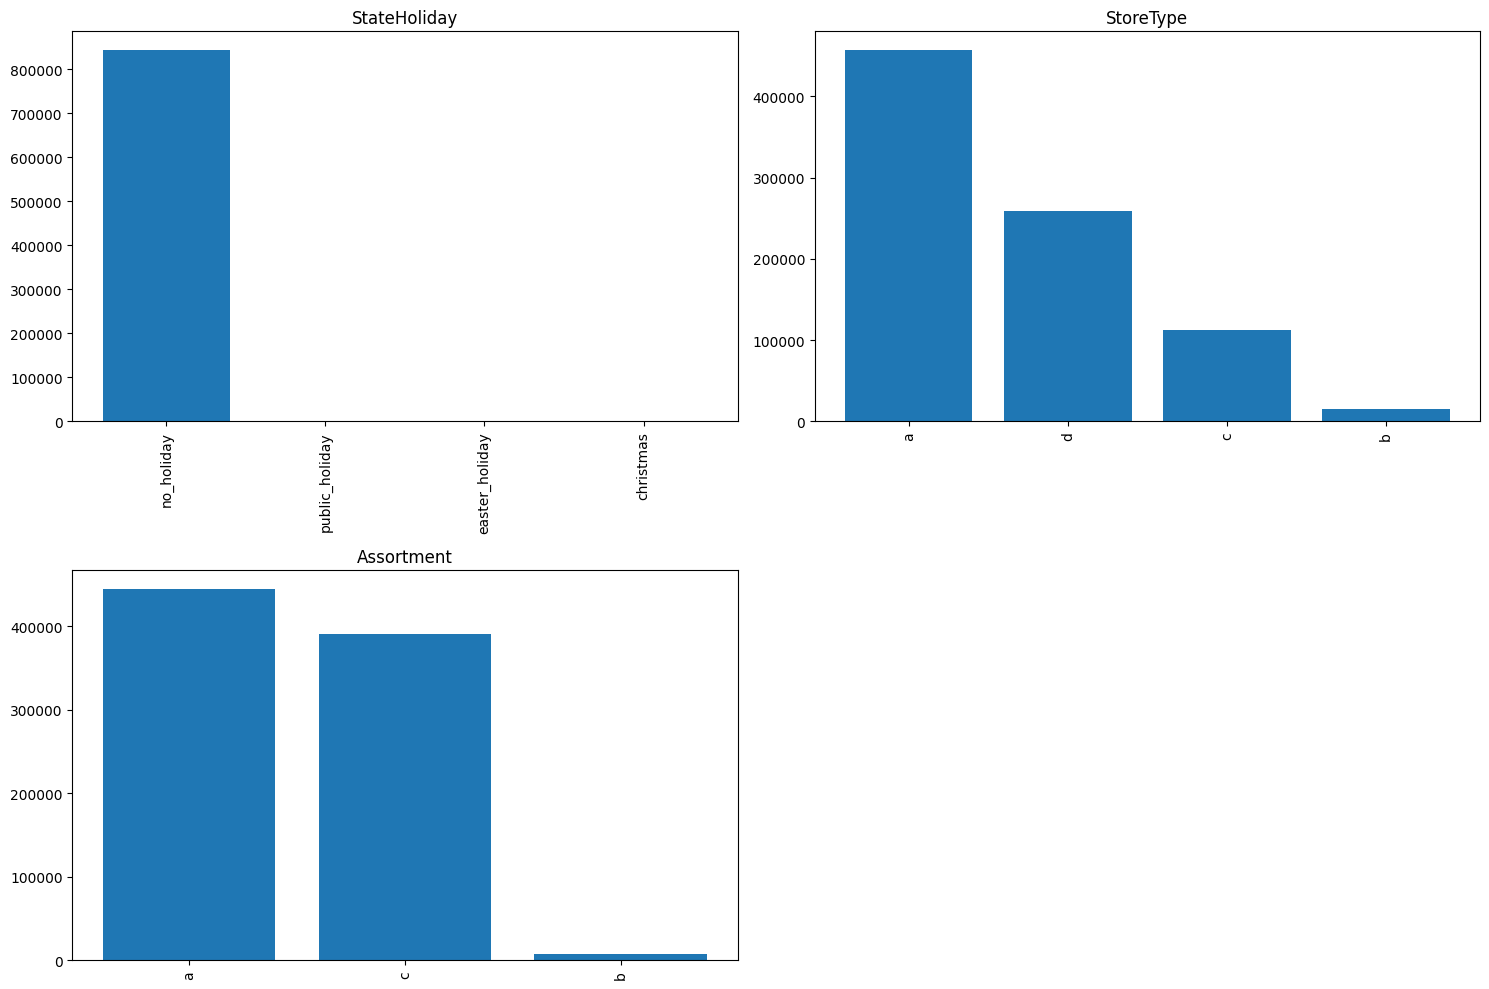

In [ ]:
def check_univariate_cat(df_eda, catCols, top_n=20):
  n = len(catCols)
  rows = -(-n // 2)
  plt.figure(figsize=(15, 5 * rows))
  for i, col in enumerate(catCols, 1):
    plt.subplot(rows, 2, i)
    counts = df_eda[col].value_counts()
    if len(counts) > top_n:
      counts = counts.head(top_n)
      plt.title(f'{col} (Top {top_n})')
    else:
      plt.title(col)
    plt.bar(counts.index, counts.values)
    plt.xticks(rotation=90)
  plt.tight_layout()
  plt.show()

check_univariate_cat(df_eda, categorical_col)

#### *Numerical*

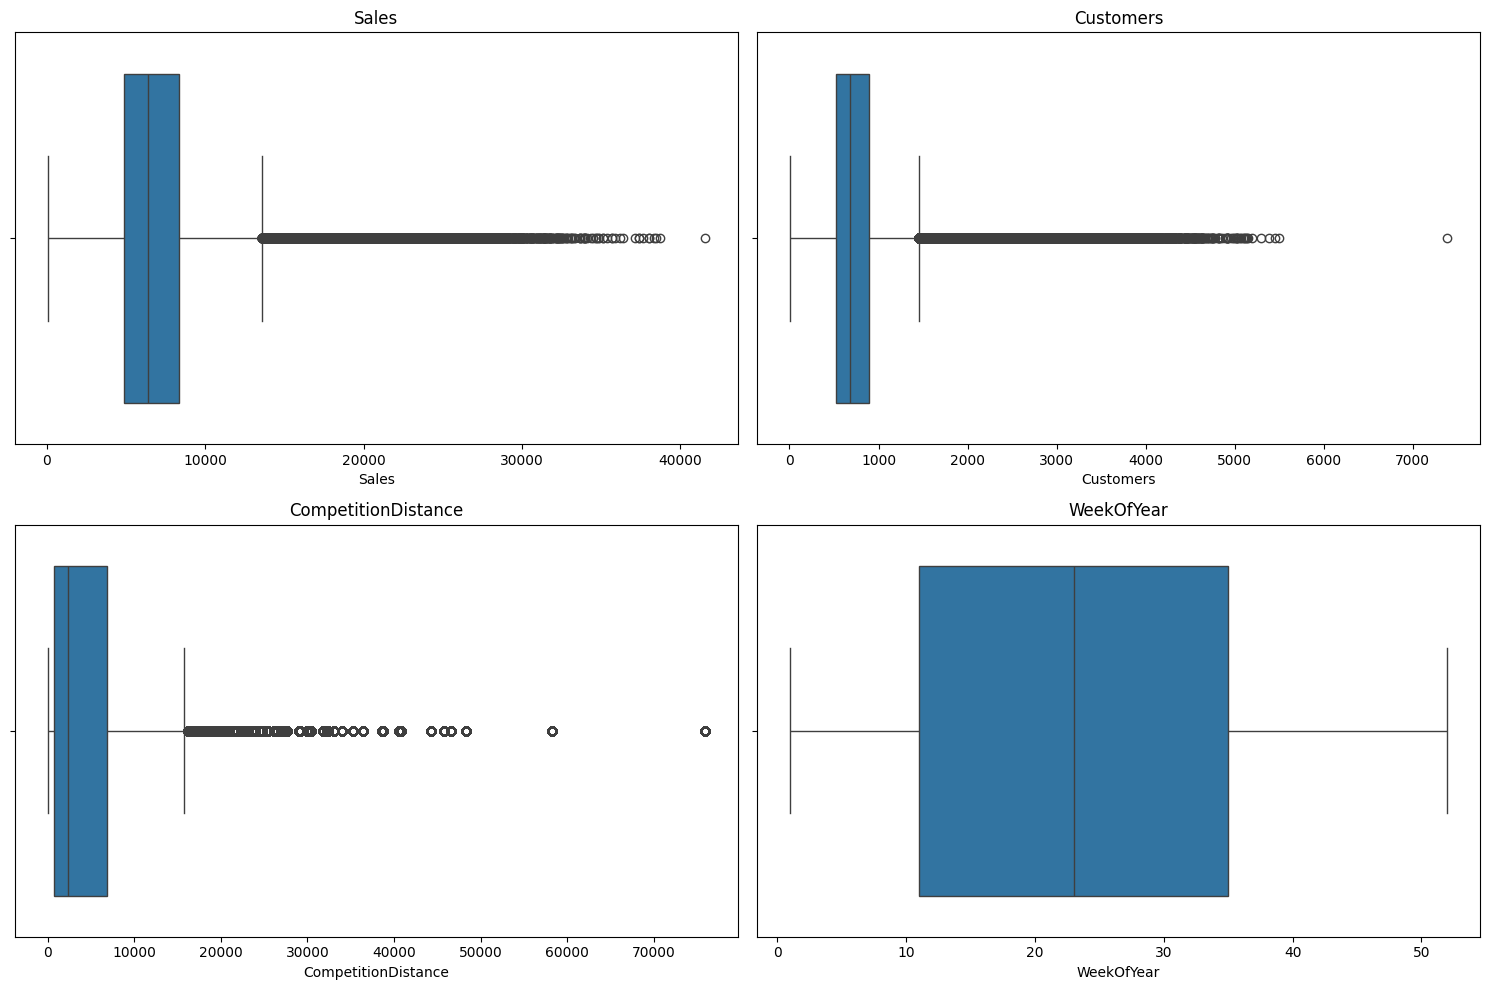

In [ ]:
def check_univariate_num(df_eda, numCols):
  n = len(numCols)
  rows = -(-n // 2)
  plt.figure(figsize=(15, 5 * rows))
  for i, col in enumerate(numCols, 1):
    plt.subplot(rows, 2, i)
    sns.boxplot(data=df_eda, x=col)
    plt.title(col)
    plt.ylabel('')
  plt.tight_layout()
  plt.show()

check_univariate_num(df_eda, numerical_col)

### **Bivariate**

#### *Numerical vs. Sales*

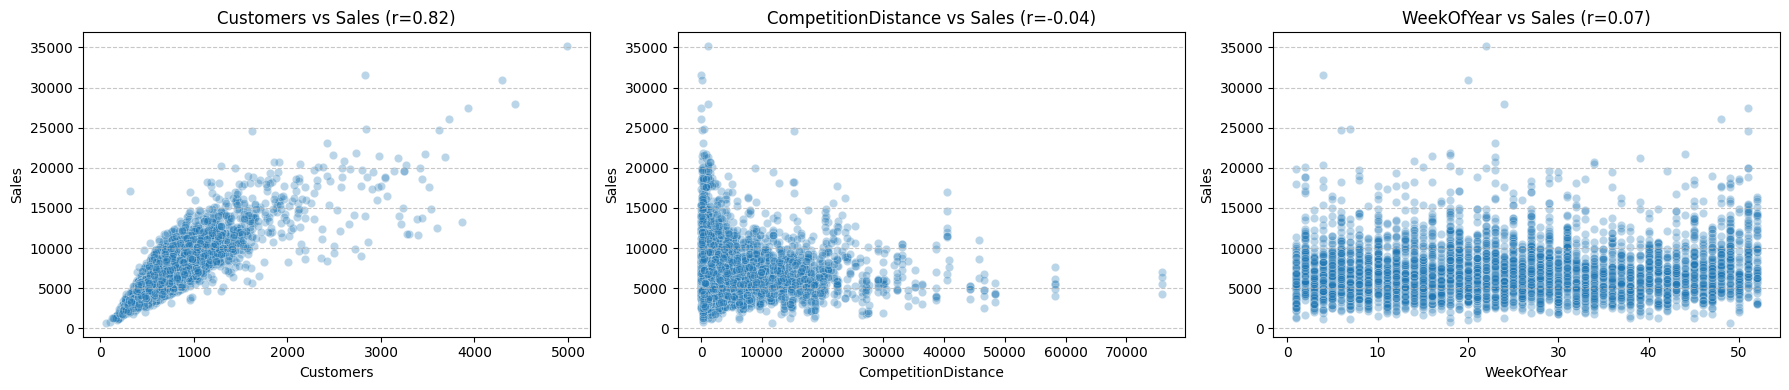

In [ ]:
TARGET = 'Sales'

def check_biv_num(df_eda, targetCol, numCols):
  numCol_to_plot = [col for col in numCols if col != targetCol]
  n = len(numCol_to_plot)
  rows = -(-n // 3)
  plt.figure(figsize=(18, 4 * rows))
  for i, col in enumerate(numCol_to_plot, 1):
    plt.subplot(rows, 3, i)
    sns.scatterplot(data=df_eda.sample(5000, random_state=42), x=col, y=targetCol, alpha=0.3)
    corr, _ = pearsonr(df_eda[col].dropna(), df_eda.loc[df_eda[col].notna(), targetCol])
    plt.title(f'{col} vs {targetCol} (r={corr:.2f})')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.tight_layout()
  plt.show()

check_biv_num(df_eda, TARGET, numerical_col)

#### *Categorical vs. Sales*

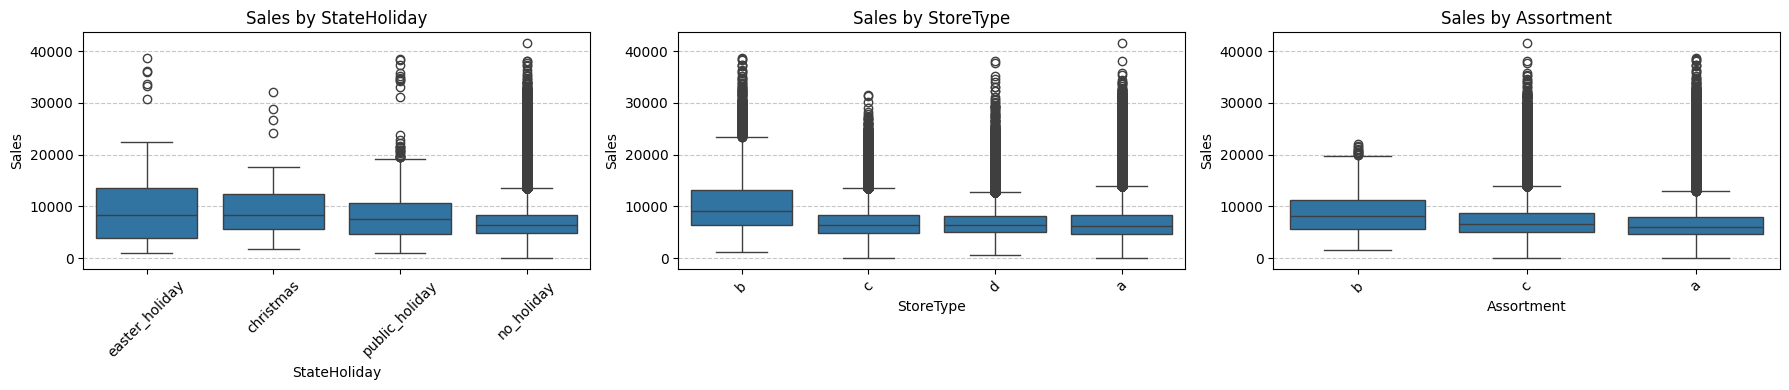

In [ ]:
def check_biv_cat(df_eda, targetCol, catCols):
  catCol_to_plot = [col for col in catCols if col != targetCol]
  n = len(catCol_to_plot)
  rows = -(-n // 3)
  plt.figure(figsize=(18, 4 * rows))
  for i, col in enumerate(catCol_to_plot, 1):
    plt.subplot(rows, 3, i)
    order = df_eda.groupby(col)[targetCol].median().sort_values(ascending=False).index
    sns.boxplot(data=df_eda, x=col, y=targetCol, order=order)
    plt.title(f'Sales by {col}')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.tight_layout()
  plt.show()

check_biv_cat(df_eda, TARGET, categorical_col)

### **Time Series Analysis**

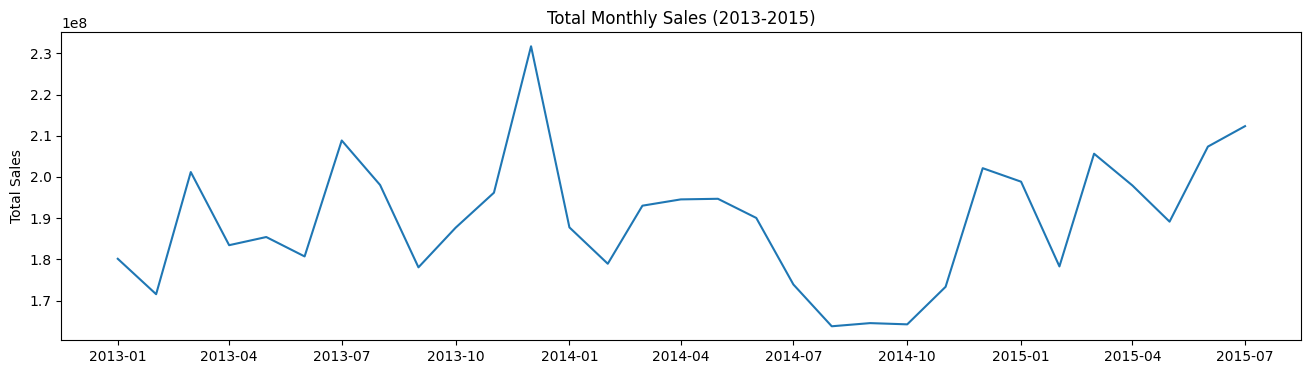

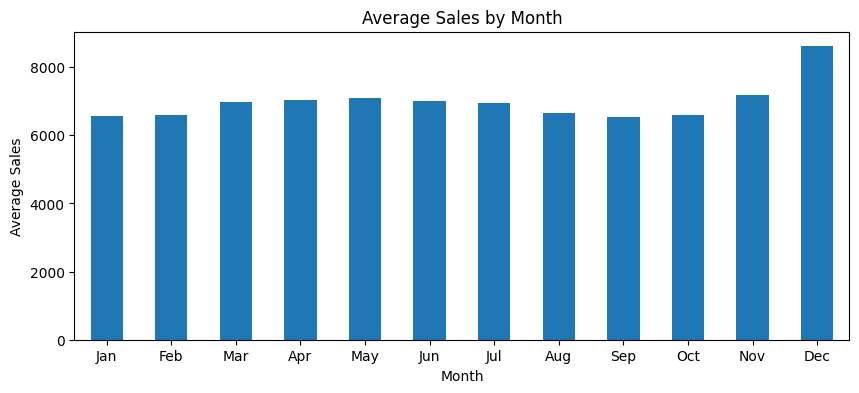

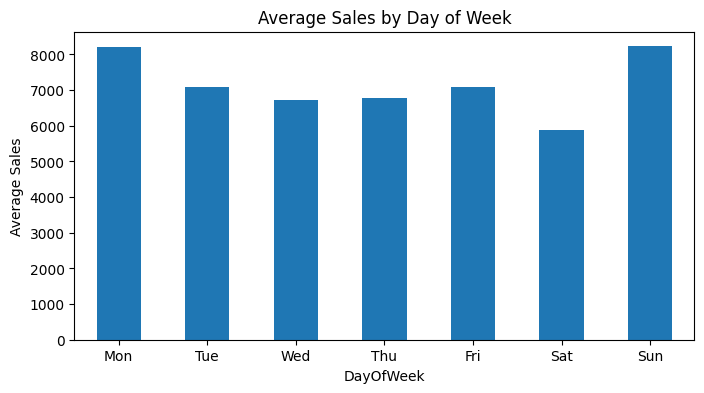

In [ ]:
# Monthly Trend
monthly_sales = df_eda.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['YearMonth'] = pd.to_datetime(monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str).str.zfill(2))

plt.figure(figsize=(16, 4))
plt.plot(monthly_sales['YearMonth'], monthly_sales['Sales'])
plt.title('Total Monthly Sales (2013-2015)')
plt.ylabel('Total Sales')
plt.show()

# Average Sales by Month
month_avg = df_eda.groupby('Month')['Sales'].mean()
month_avg.plot(kind='bar', figsize=(10, 4))
plt.title('Average Sales by Month')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
plt.ylabel('Average Sales')
plt.show()

# Average Sales by Day of Week
dow_avg = df_eda.groupby('DayOfWeek')['Sales'].mean()
dow_avg.plot(kind='bar', figsize=(8, 4))
plt.title('Average Sales by Day of Week')
plt.xticks(range(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)
plt.ylabel('Average Sales')
plt.show()

In [ ]:
mid_2014 = df_eda[(df_eda['Year'] == 2014) & (df_eda['Month'].between(7, 9))] # NOTES: Cuma buat check sebentar, karena ada penurunan angka signifikan pada rentang waktu tersebut.
print(mid_2014.groupby('Month')['Store'].nunique())

print(df_eda.groupby(['Year', 'Month'])['Sales'].sum().unstack('Year'))

print(df_eda[df_eda['Year'] == 2013].groupby('Month')['Promo'].mean())
print(df_eda[df_eda['Year'] == 2014].groupby('Month')['Promo'].mean())

Month
7    934
8    934
9    934
Name: Store, dtype: int64
Year          2013         2014         2015
Month                                       
1      180132207.0  187752787.0  198843730.0
2      171534275.0  178924677.0  178275458.0
3      201180369.0  193019854.0  205631683.0
4      183431432.0  194544977.0  197918886.0
5      185411063.0  194693257.0  189143897.0
6      180702351.0  190047051.0  207363373.0
7      208843882.0  173892707.0  212322616.0
8      198042727.0  163748475.0          NaN
9      178053963.0  164516168.0          NaN
10     187662330.0  164216398.0          NaN
11     196170924.0  173327953.0          NaN
12     231710561.0  202120592.0          NaN
Month
1     0.383232
2     0.415973
3     0.557814
4     0.477330
5     0.483873
6     0.397795
7     0.479313
8     0.439863
9     0.397856
10    0.384615
11    0.389800
12    0.414483
Name: Promo, dtype: float64
Month
1     0.376912
2     0.415662
3     0.420996
4     0.455920
5     0.437957
6     0.440841
7

## **Hypotsis and Experimental Testing**


---



### **Experimental A/B Testing: Promo vs No Promo**

- Group A (Control)  : Stores without promotion (Promo = 0)
- Group B (Treatment) : Stores with promotion (Promo = 1)
- H0: There is no significant difference in Sales between Group A and Group B
- H1: There is a significant difference in Sales between Group A and Group B

In [ ]:
group_a = df_eda[df_eda['Promo'] == 0]['Sales']  # Control
group_b = df_eda[df_eda['Promo'] == 1]['Sales']  # Treatment

stat_ab, p_value_ab = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')

print("A/B Testing: Promo vs No Promo")
print(f"U Statistic: {stat_ab:,.0f}")
print(f"P-Value: {p_value_ab:.4e}")
print(f"Result: {'Significant (reject H0)' if p_value_ab < 0.05 else 'Not Significant (fail to reject H0)'}")
print()
print(f"Mean Sales: Group A (No Promo): {group_a.mean():,.2f}")
print(f"Mean Sales: Group B (Promo): {group_b.mean():,.2f}")
print(f"Lift: {((group_b.mean() - group_a.mean()) / group_a.mean() * 100):.1f}%")

A/B Testing: Promo vs No Promo
U Statistic: 45,073,973,080
P-Value: 0.0000e+00
Result: Significant (reject H0)

Mean Sales: Group A (No Promo): 5,929.83
Mean Sales: Group B (Promo): 8,228.74
Lift: 38.8%


### **Statistical Hypothesis Testing: Sales across StoreTypes**

- H0: There is no significant difference in Sales across StoreTypes (a, b, c, d)
- H1: There is a significant difference in Sales across at least one StoreType

In [ ]:
groups = [df_eda[df_eda['StoreType'] == st]['Sales'] for st in ['a', 'b', 'c', 'd']]

stat_kw, p_value_kw = stats.kruskal(*groups)

print(f"Kruskal-Wallis Test: Sales across StoreTypes")
print(f"H Statistic: {stat_kw:,.2f}")
print(f"P-Value: {p_value_kw:.6f}")
print(f"Result: {'Significant (reject H0)' if p_value_kw < 0.05 else 'Not Significant (fail to reject H0)'}")
print()
for st, g in zip(['a', 'b', 'c', 'd'], groups):
    print(f"Mean Sales: StoreType {st.upper()}: {g.mean():,.2f}")

Kruskal-Wallis Test: Sales across StoreTypes
H Statistic: 8,227.55
P-Value: 0.000000
Result: Significant (reject H0)

Mean Sales: StoreType A: 6,925.70
Mean Sales: StoreType B: 10,233.38
Mean Sales: StoreType C: 6,933.13
Mean Sales: StoreType D: 6,822.30


## **Pattern & Insight**

---



#### *NOTES: Ini bagian tambahan untuk melihat hubungan lebih dalam antar variable.*

In [ ]:
# Pastikan kolom StateHoliday dibaca sebagai string untuk menghindari error
df['StateHoliday'] = df['StateHoliday'].astype(str)

# Cara cepat melihat semua distribusi libur
print(df['StateHoliday'].value_counts())

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64


### **Promo Effect**

Promo
0    5929.826183
1    8228.739731
Name: Sales, dtype: float64
Promo uplift: 38.77%


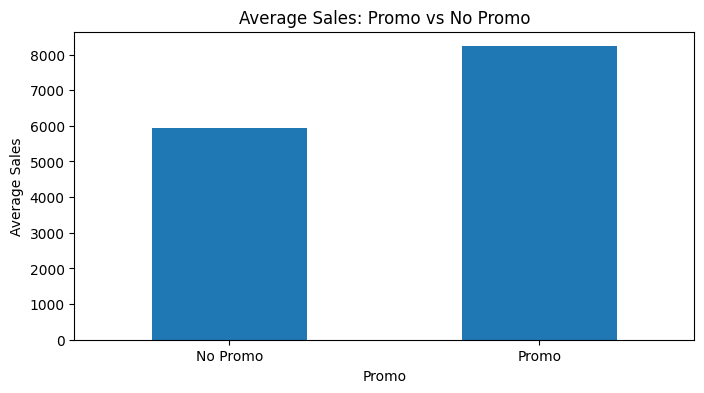

In [ ]:
promo_avg = df_eda.groupby('Promo')['Sales'].mean()
print(promo_avg)

uplift = (promo_avg[1] - promo_avg[0]) / promo_avg[0] * 100
print(f'Promo uplift: {uplift:.2f}%')

promo_avg.plot(kind='bar', figsize=(8, 4))
plt.xticks([0, 1], ['No Promo', 'Promo'], rotation=0)
plt.title('Average Sales: Promo vs No Promo')
plt.ylabel('Average Sales')
plt.show()

### S**toreType**

StoreType
b    10233.380141
c     6933.126425
a     6925.697986
d     6822.300064
Name: Sales, dtype: float64


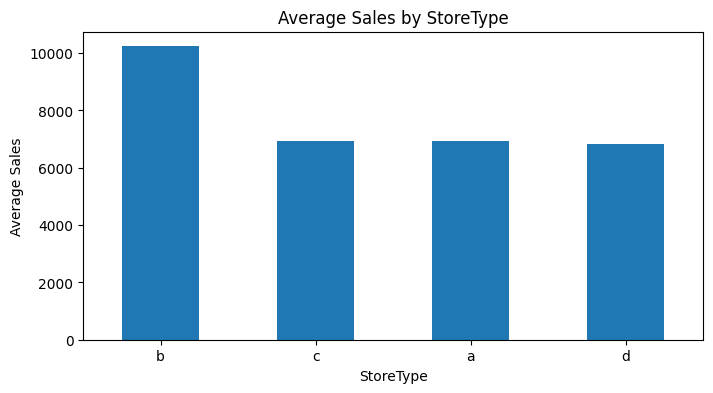

In [ ]:
storetype_avg = df_eda.groupby('StoreType')['Sales'].mean().sort_values(ascending=False)
print(storetype_avg)

storetype_avg.plot(kind='bar', figsize=(8, 4))
plt.title('Average Sales by StoreType')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.show()

### **Competitor**

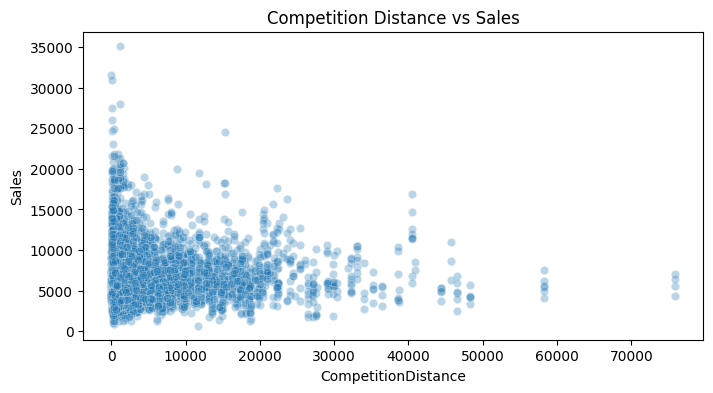

In [ ]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df_eda.sample(5000, random_state=42), x='CompetitionDistance', y='Sales', alpha=0.3)
plt.title('Competition Distance vs Sales')
plt.show()

#### **Yearly Growth**

Year
2013    6814.775168
2014    7026.128505
2015    7088.235123
Name: Sales, dtype: float64


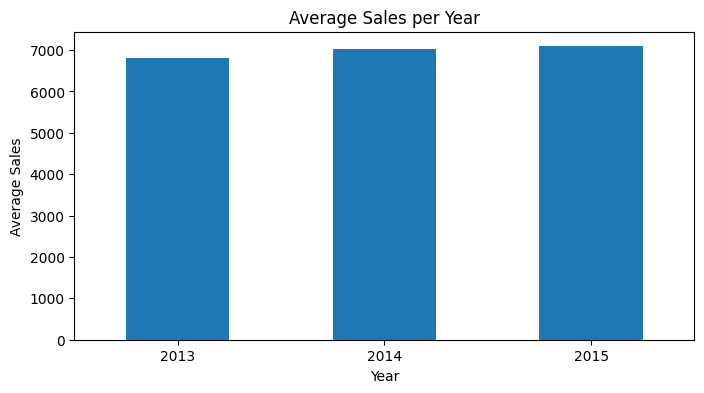

In [ ]:
yearly_avg = df_eda.groupby('Year')['Sales'].mean()
print(yearly_avg)

yearly_avg.plot(kind='bar', figsize=(8, 4))
plt.title('Average Sales per Year')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.show()

#### **Holiday Effect**

StateHoliday
easter_holiday    9887.889655
christmas         9743.746479
public_holiday    8487.471182
no_holiday        6953.960229
Name: Sales, dtype: float64


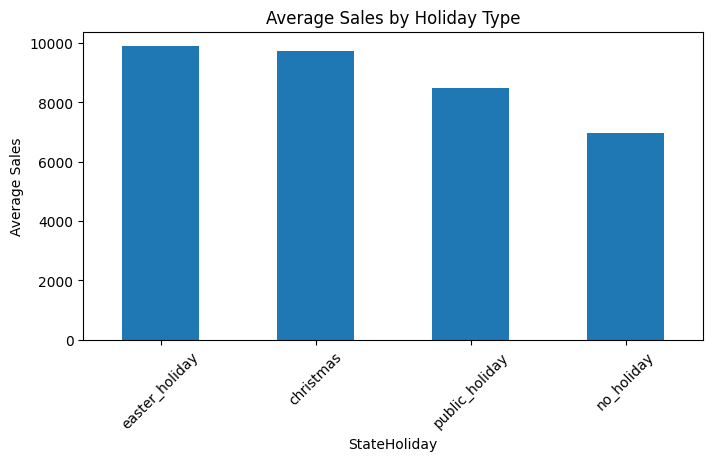

In [ ]:
holiday_avg = df_eda.groupby('StateHoliday')['Sales'].mean().sort_values(ascending=False)
print(holiday_avg)

holiday_avg.plot(kind='bar', figsize=(8, 4))
plt.title('Average Sales by Holiday Type')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.show()

#### **Promo per StoreType**

              No Promo         Promo
StoreType                           
a          5809.052116   8304.548971
b          9567.855955  11311.802796
c          6028.547554   8042.788106
d          5855.391063   8018.036562


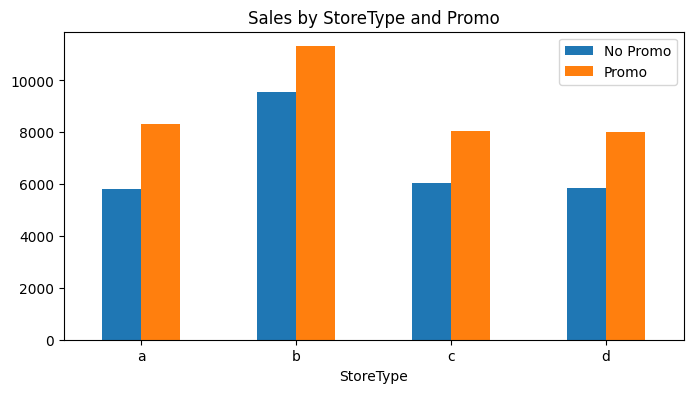

In [ ]:
promo_store = df_eda.groupby(['StoreType', 'Promo'])['Sales'].mean().unstack()
promo_store.columns = ['No Promo', 'Promo']
print(promo_store)

promo_store.plot(kind='bar', figsize=(8, 4))
plt.title('Sales by StoreType and Promo')
plt.xticks(rotation=0)
plt.show()

## **Modeling**

---



### **Data Preparation for Modeling**

In [ ]:
df_model = df_eda.copy()

In [ ]:
print(df_model.dtypes)

Store                                 int64
DayOfWeek                             int64
Date                         datetime64[ns]
Sales                                 int64
Customers                             int64
Promo                                 int64
StateHoliday                         object
SchoolHoliday                         int64
StoreType                            object
Assortment                           object
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object
Year                                  int32
Month                                 int32
WeekOfYear                            int64
Quarter                               int32
dtype: object


In [ ]:
# Melakukan pengurutan data terlebih dahulu sebelum di drop column Date-nya
df_model = df_model.sort_values('Date').reset_index(drop=True)

drop_cols = ['Date', 'Customers', 'CompetitionCategory']
df_model = df_model.drop(columns=[col for col in drop_cols if col in df_model.columns])
df_model = df_model.reset_index(drop=True)

print(f'Shape df_model: {df_model.shape}')
print(df_model.dtypes)

Shape df_model: (844338, 19)
Store                          int64
DayOfWeek                      int64
Sales                          int64
Promo                          int64
StateHoliday                  object
SchoolHoliday                  int64
StoreType                     object
Assortment                    object
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                 object
Year                           int32
Month                          int32
WeekOfYear                     int64
Quarter                        int32
dtype: object


print(f'Shape df_model: {df_model.shape}')
print(df_model.dtypes)

### **Encoding & Feature Type Seperation**

In [ ]:
numerical_cols_model   = df_model.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols_model = df_model.select_dtypes(include='object').columns.tolist()

print('Numerical  :', numerical_cols_model)
print('Categorical:', categorical_cols_model)

TARGET = 'Sales'

# Label Encoding untuk kolom kategorikal
le = LabelEncoder()
for col in categorical_cols_model:
    df_model[col] = le.fit_transform(df_model[col])

print('\nSetelah encoding:')
print(df_model[categorical_cols_model].head())

Numerical  : ['Store', 'DayOfWeek', 'Sales', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'WeekOfYear']
Categorical: ['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']

Setelah encoding:
   StateHoliday  StoreType  Assortment  PromoInterval
0             3          1           1              3
1             3          1           0              3
2             3          1           1              3
3             3          1           0              3
4             3          1           1              1


### **Train/Test Split**

In [ ]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

# Split 80% train, 20% test secara berurutan
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'Train period: {df_model.iloc[:split_idx].index[0]} → {df_model.iloc[:split_idx].index[-1]}')
print(f'Test period : {df_model.iloc[split_idx:].index[0]} → {df_model.iloc[split_idx:].index[-1]}')

X_train: (675470, 18)
X_test : (168868, 18)
Train period: 0 → 675469
Test period : 675470 → 844337


In [ ]:

df_train_temp = X_train.copy()
df_train_temp[TARGET] = y_train.values

store_avg = df_train_temp.groupby('Store')[TARGET].mean()
store_month_avg = df_train_temp.groupby(['Store', 'Month'])[TARGET].mean()
global_avg = store_month_avg.mean()  # Fallback jika kombinasi tidak ditemukan

# Map ke train
X_train['StoreAvgSales'] = X_train['Store'].map(store_avg)
X_train['StoreMonthAvg'] = X_train.apply(
    lambda row: store_month_avg.get((row['Store'], row['Month']), global_avg), axis=1
)

# Map ke test
X_test['StoreAvgSales'] = X_test['Store'].map(store_avg)
X_test['StoreMonthAvg'] = X_test.apply(
    lambda row: store_month_avg.get((row['Store'], row['Month']), global_avg), axis=1
)

print('New Features Added')

New Features Added


### **Scalling**

In [ ]:
from sklearn.preprocessing import StandardScaler

numerical_cols_model = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

scaler = StandardScaler()
X_train[numerical_cols_model] = scaler.fit_transform(X_train[numerical_cols_model])
X_test[numerical_cols_model]  = scaler.transform(X_test[numerical_cols_model])

print('Scaling done')
print(X_train.head())

Scaling done
      Store  DayOfWeek     Promo  StateHoliday  SchoolHoliday  StoreType  \
0  1.674323   -0.88013 -0.897416     27.355577       2.001055  -0.148983   
1 -1.471221   -0.88013 -0.897416     27.355577       2.001055  -0.148983   
2 -0.930386   -0.88013 -0.897416     27.355577       2.001055  -0.148983   
3 -0.921062   -0.88013 -0.897416     27.355577       2.001055  -0.148983   
4 -0.883763   -0.88013 -0.897416     27.355577       2.001055  -0.148983   

   Assortment  CompetitionDistance  CompetitionOpenSinceMonth  \
0    0.062272            -0.606098                  -0.449480   
1   -0.944571            -0.458880                   1.184477   
2    0.062272            -0.671386                  -1.149748   
3   -0.944571            -0.547211                   0.017365   
4    0.062272            -0.232291                  -1.149748   

   CompetitionOpenSinceYear    Promo2  Promo2SinceWeek  Promo2SinceYear  \
0                  0.676068 -0.991653        -0.753193        -0

### **Feature Selection**

                      Feature  MI Score
19              StoreMonthAvg  0.492223
18              StoreAvgSales  0.487245
0                       Store  0.380165
7         CompetitionDistance  0.214075
2                       Promo  0.096037
16                 WeekOfYear  0.058172
1                   DayOfWeek  0.042697
11            Promo2SinceWeek  0.023334
12            Promo2SinceYear  0.020947
9    CompetitionOpenSinceYear  0.020160
5                   StoreType  0.016431
15                      Month  0.014274
8   CompetitionOpenSinceMonth  0.013967
13              PromoInterval  0.013436
10                     Promo2  0.011289
6                  Assortment  0.008350
17                    Quarter  0.005141
4               SchoolHoliday  0.001404
14                       Year  0.000901
3                StateHoliday  0.000540


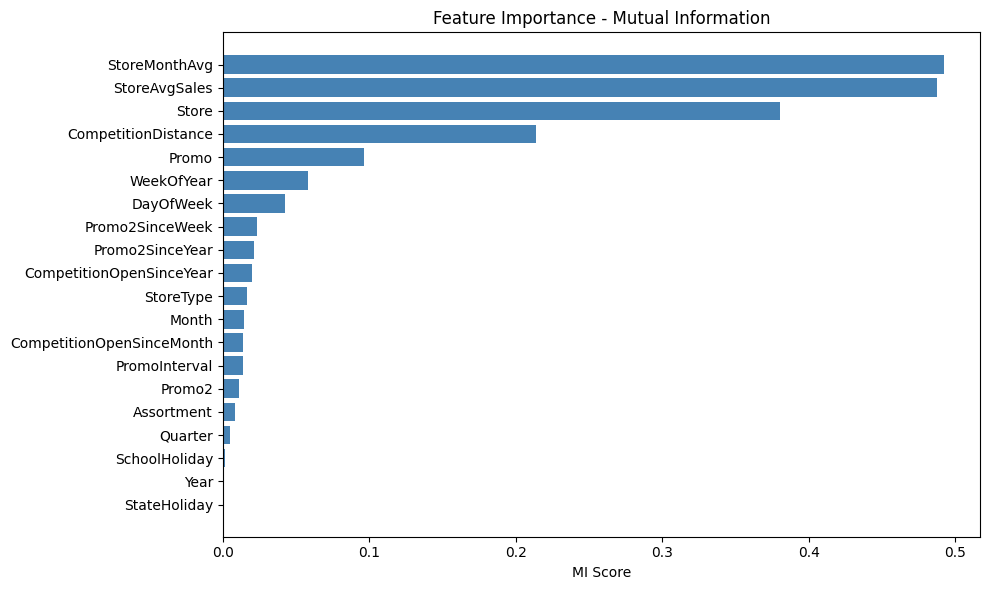

In [ ]:
mi_score = mutual_info_regression(X_train, y_train)
mi_df = pd.DataFrame({
    'Feature'  : X_train.columns,
    'MI Score' : mi_score
}).sort_values('MI Score', ascending=False)

print(mi_df)

# Visualisasi MI Score
plt.figure(figsize=(10, 6))
plt.barh(mi_df['Feature'], mi_df['MI Score'], color='steelblue')
plt.title('Feature Importance - Mutual Information')
plt.xlabel('MI Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### **Select Features**

In [ ]:
selected_features = mi_df[mi_df['MI Score'] > 0]['Feature'].tolist()
print('Selected features:', selected_features)

X_train_selected = X_train[selected_features]
X_test_selected  = X_test[selected_features]

Selected features: ['StoreMonthAvg', 'StoreAvgSales', 'Store', 'CompetitionDistance', 'Promo', 'WeekOfYear', 'DayOfWeek', 'Promo2SinceWeek', 'Promo2SinceYear', 'CompetitionOpenSinceYear', 'StoreType', 'Month', 'CompetitionOpenSinceMonth', 'PromoInterval', 'Promo2', 'Assortment', 'Quarter', 'SchoolHoliday', 'Year', 'StateHoliday']


### **Model Fitting**

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=3,
    max_features=None,
    random_state=42
)

rf.fit(X_train_selected, y_train)
print('Model Traning Finish')

Model Traning Finish


### **Prediction & Evaluation**

In [ ]:
y_pred = rf.predict(X_test_selected)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE  : {mae:,.2f}')
print(f'RMSE : {rmse:,.2f}')
print(f'R²   : {r2:.4f}')

MAE  : 908.99
RMSE : 1,312.99
R²   : 0.8163


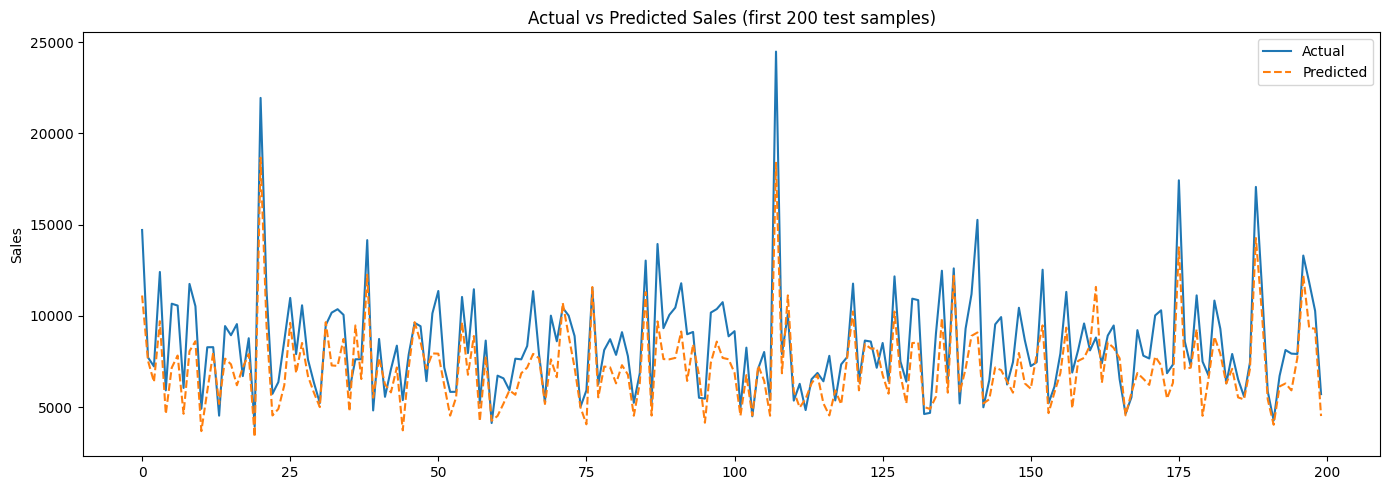

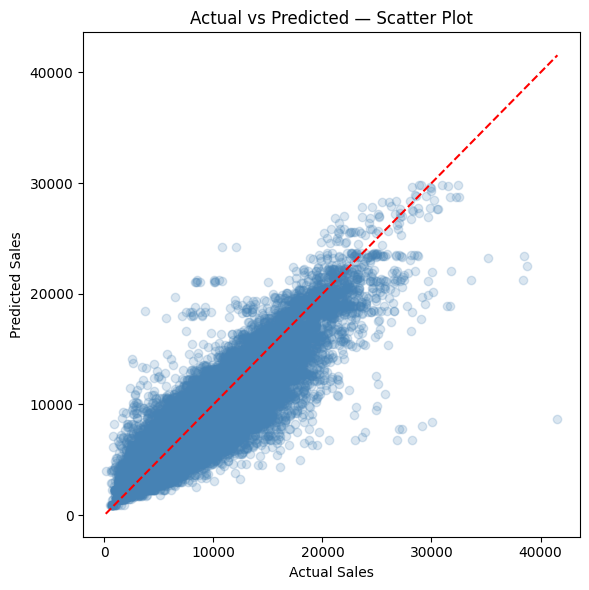

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:200], label='Actual', linewidth=1.5)
plt.plot(y_pred[:200], label='Predicted', linewidth=1.5, linestyle='--')
plt.title('Actual vs Predicted Sales (first 200 test samples)')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

# Scatter actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.2, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=1.5)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted — Scatter Plot')
plt.tight_layout()
plt.show()

### **Feature Importance**

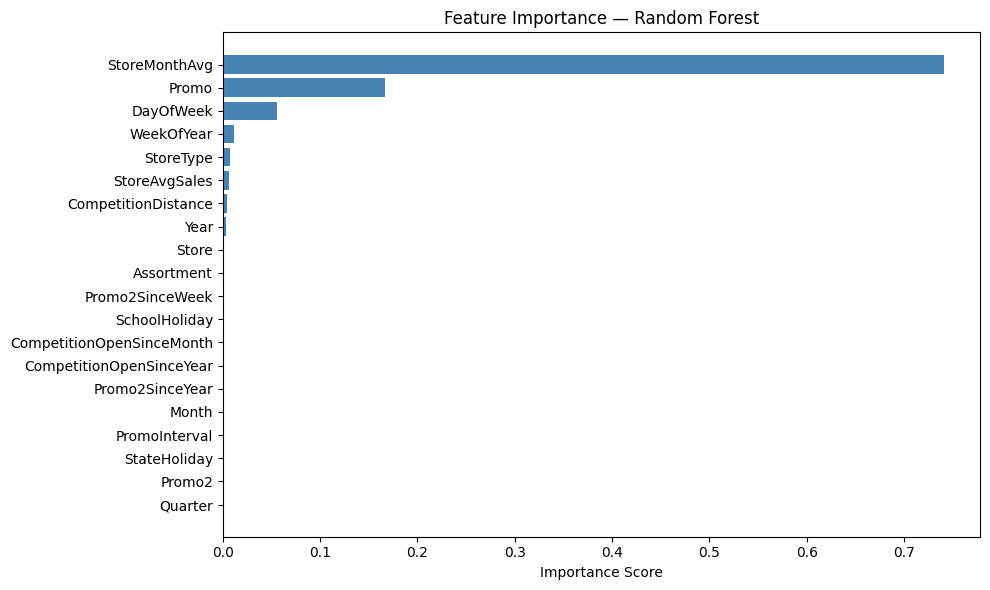

In [ ]:
feat_imp = pd.DataFrame({
    'Feature'    : X_train_selected.columns,
    'Importance' : rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## **Tuning**

---



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Sample hanya 10% dari training data untuk tuning
X_train_sample = X_train_selected.sample(frac=0.1, random_state=42)
y_train_sample = y_train[X_train_sample.index]

param_dist = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [5, 10],
    'min_samples_leaf' : [3, 5],
}

random_search = RandomizedSearchCV(
    estimator           = RandomForestRegressor(random_state=42),
    param_distributions = param_dist,
    n_iter              = 5, # kurangi jadi 5 kombinasi saja
    cv                  = 2, # kurangi jadi 2 fold
    scoring             = 'neg_mean_absolute_error',
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1
)

random_search.fit(X_train_sample, y_train_sample)
print(f'Best params: {random_search.best_params_}')

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best params: {'n_estimators': 200, 'min_samples_leaf': 3, 'max_depth': 10}


In [ ]:
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test_selected)

mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned   = r2_score(y_test, y_pred_tuned)

print('=== Sebelum Tuning ===')
print(f'MAE  : {mae:,.2f}')
print(f'RMSE : {rmse:,.2f}')
print(f'R²   : {r2:.4f}')

print('\n=== Setelah Tuning ===')
print(f'MAE  : {mae_tuned:,.2f}')
print(f'RMSE : {rmse_tuned:,.2f}')
print(f'R²   : {r2_tuned:.4f}')

=== Sebelum Tuning ===
MAE  : 908.99
RMSE : 1,312.99
R²   : 0.8163

=== Setelah Tuning ===
MAE  : 919.86
RMSE : 1,332.27
R²   : 0.8109
